In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Merging the Data

In [26]:
SteamReviewsData = pd.read_csv('Data1-steam.csv')
VideoGamesData = pd.read_csv('Data2-videoGames.csv')

# print(SteamReviewsData.to_string()) 
# print(VideoGamesData.to_string()) 

VideoGamesData["match_key"] = VideoGamesData["Name"].str.strip().str.lower()
SteamReviewsData["match_key"] = SteamReviewsData["name"].str.strip().str.lower()

ColumnsSteamReviewsData = SteamReviewsData[["match_key", "genres", "positive_ratings", "negative_ratings"]].copy()

ColumnsSteamReviewsData["steam_total_reviews"] = ColumnsSteamReviewsData["positive_ratings"] + ColumnsSteamReviewsData["negative_ratings"]

ColumnsSteamReviewsData["steam_positive_review_ratio"] = ColumnsSteamReviewsData["positive_ratings"] / ColumnsSteamReviewsData["steam_total_reviews"]

ColumnsSteamReviewsData.drop(columns=["positive_ratings", "negative_ratings"], inplace=True)

MergedData = pd.merge(VideoGamesData, ColumnsSteamReviewsData, how='left', on='match_key')

MergedData.drop(columns=["match_key"], inplace=True)
MergedData.to_csv('MergedData.csv', index=False)

# print(MergedData.to_string()) 

# Cleaning and Imputation of Missing Data

### Cleaning and preparing player reviews

In [27]:
#round the steam score to 1 decimal place and scale it up so its values are betwwen 0 and 10
MergedData['steam_score'] = (MergedData['steam_positive_review_ratio'] * 10).round(1)

Producting single player score
* Scenario 1: Only User_Score available -> use it 
* Scenario 2: Only steam_score available -> use it 
* Scenario 3: Both available -> get standard weighted average 
    * I found out which kind of average I need using Gemini AI with this prompt: I have a pandas .cvs file where some of my User_Count column is low in number (max ~8,715), while my steam_total_reviews column is extremely high in number (30k+ is common). I need to calculate a weighted average of User_Score and steam_score. What kind of average do i need?
        * no code was taken from  Gemini

In [28]:
#scenarios 1 and 2
rowHasSteamScore = MergedData['steam_score'].notna()
rowHasUserScore = MergedData['User_Score'].notna()

#scenario 3
MergedData['Weight_User_Count'] = np.log1p(MergedData['User_Count']) #e.g. 8000 becomes 9.0
MergedData['Weight_Steam_Reviews'] = np.log1p(MergedData['steam_total_reviews']) #e.g. 35000 becomes 10.5

MergedData['total_u_score_weight'] = MergedData['Weight_User_Count'] + MergedData['Weight_Steam_Reviews']

# avg
scenario3 = ((MergedData['User_Score'] * MergedData['Weight_User_Count']) +  (MergedData['steam_score'] * MergedData['Weight_Steam_Reviews'])) / MergedData['total_u_score_weight']


# Apply scenarios
conditions = [
    rowHasUserScore & ~rowHasSteamScore,   # Scenario 1 
    ~rowHasUserScore & rowHasSteamScore,   # Scenario 2 
    rowHasUserScore & rowHasSteamScore ]  # Scenario 3 

choices = [
    MergedData['User_Score'], # Scenario 1 
    MergedData['steam_score'], # Scenario 2
    scenario3] # Scenario 3

# MergedData['transformed_user_score'] = np.select(conditions, choices, 0)
MergedData['transformed_user_score'] = np.select(conditions, choices, default=np.nan)


MergedData['transformed_user_score'] = (MergedData['transformed_user_score']).round(1)
MergedData = MergedData.drop(columns=['Weight_User_Count', 'Weight_Steam_Reviews', 'total_u_score_weight'])

# remove rows which don't have a final score
rows_before_Uscore_clean = len(MergedData)

rows_before = len(MergedData)
MergedData = MergedData[MergedData['transformed_user_score'].notna()]

rows_after_Uscore_clean = len(MergedData)
print(f"Number of dropped rows: {rows_before - rows_after_Uscore_clean}")
print(f"Number of remaining rows: {rows_after_Uscore_clean}")

# MergedData.to_csv('MergedData_clean.csv', index=False)

Number of dropped rows: 9364
Number of remaining rows: 8061


### Cleaning and preparing critic reviews

In [29]:

genreMedianCritic = MergedData.groupby('Genre')['Critic_Score'].transform('median')
MergedData['Critic_Score'] = MergedData['Critic_Score'].fillna(genreMedianCritic)

genreMedianCriticCunt =  MergedData.groupby('Genre')['Critic_Count'].transform('median')
MergedData['Critic_Count'] = MergedData['Critic_Count'].fillna(genreMedianCriticCunt)

MergedData = MergedData.drop(columns=['steam_positive_review_ratio', 'steam_score', 'genres', 'steam_total_reviews', 'Rating'])
MergedData.to_csv('MergedData_cleaned.csv', index=False)


### Dealing with outliers

#### Visually display outliers

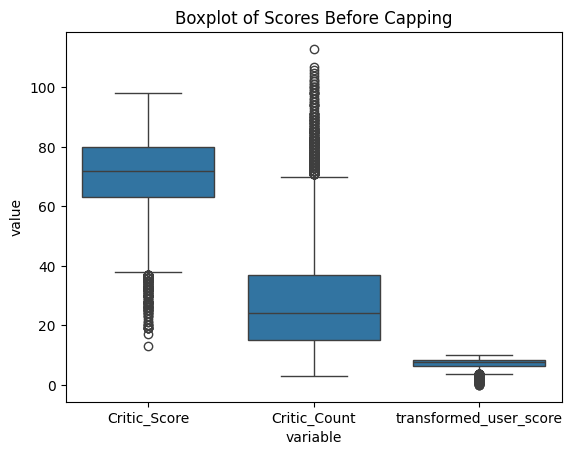

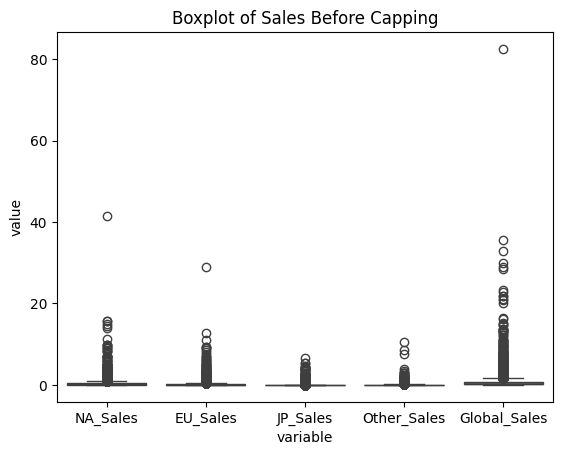

In [30]:
lower_percentile = 0.01
higher_percentile = 0.99


salesColumns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
scoreColumns = ['Critic_Score', 'Critic_Count', 'transformed_user_score']


sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[scoreColumns]))
plt.title('Boxplot of Scores Before Capping')
plt.show()  

sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[salesColumns]))
plt.title('Boxplot of Sales Before Capping')
plt.show()


MergedData.to_csv('MergedData_cleaned.csv', index=False)

#### Capping outliers

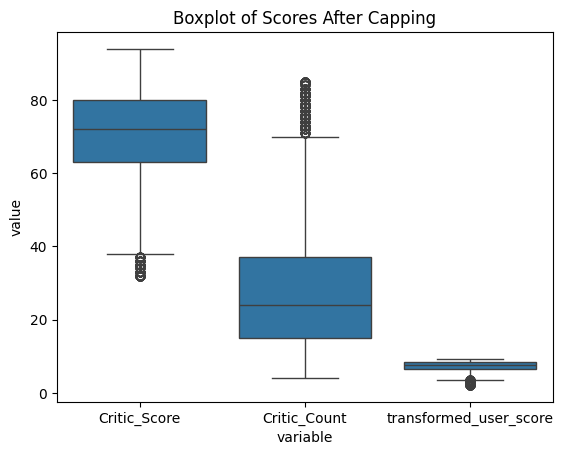

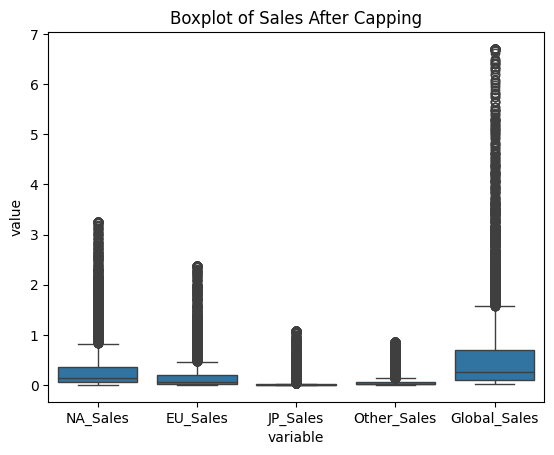

In [31]:
for column in salesColumns:
    low, high = MergedData[column].quantile([lower_percentile, higher_percentile])
    MergedData[column] = np.where(MergedData[column] > high, high, 
                         np.where(MergedData[column] < low, low, 
                         MergedData[column]))

for column in scoreColumns:
    low, high = MergedData[column].quantile([lower_percentile, higher_percentile])
    MergedData[column] = np.where(MergedData[column] > high, high, 
                         np.where(MergedData[column] < low, low, 
                         MergedData[column]))
    
sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[scoreColumns]))
plt.title('Boxplot of Scores After Capping')
plt.show()  

sns.boxplot(x="variable", y="value", data=pd.melt(MergedData[salesColumns]))
plt.title('Boxplot of Sales After Capping')
plt.show()

### Dealing with duplicates

In [33]:
duplicatedNamesAndPlatforms = MergedData[MergedData.duplicated(subset=['Name', 'Platform'], keep=False)]
print(duplicatedNamesAndPlatforms.to_string())

rowsBeforeRemovingDuplicates = len(MergedData)
MergedData = MergedData.drop_duplicates(subset=['Name', 'Platform'], keep='first')
rowsAfterRemovingDuplicates = len(MergedData)

print(f"Number of dropped rows: {rowsBeforeRemovingDuplicates - rowsAfterRemovingDuplicates}")
print(f"Number of remaining rows: {rowsAfterRemovingDuplicates}")

                                     Name Platform  Year_of_Release       Genre           Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  Critic_Count  User_Score  User_Count  transformed_user_score
605                         Madden NFL 13      PS3           2012.0      Sports     Electronic Arts      2.12      0.22     0.000         0.23          2.57          83.0          22.0         5.5       101.0                     5.5
776                               Mahjong      NES           1983.0        Misc            Nintendo      0.01      0.00     1.084         0.00          2.14          71.0          20.0         NaN         NaN                     7.6
777                               Mahjong      NES           1983.0        Misc            Nintendo      0.01      0.00     1.084         0.00          2.14          71.0          20.0         NaN         NaN                     6.0
1180                       SoulCalibur IV     X360           2008.0 